# 03. Player analysis

**Question:** which player numbers are repeatable, and which are mostly noise?

If a stat reflects a real skill, players who are high one season should tend to be high the next. So for
players with at least 450 minutes in back-to-back Champions League seasons, correlate each stat with the
same stat a year later.

In [1]:
import sys
from pathlib import Path

# Let the notebook import from src/ when it's run from the notebooks folder.
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.database.connection import read_sql

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "axes.edgecolor": "#c3c2b7",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]),
})
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"

In [2]:
players = read_sql('''
    SELECT season_year, player_id, player_name,
           SUM(minutes) AS minutes, SUM(non_penalty_goals) AS np_goals, SUM(non_penalty_shots) AS np_shots,
           SUM(non_penalty_shots_on_target) AS np_sot, SUM(assists) AS assists
    FROM v_player_season_stats
    GROUP BY season_year, player_id, player_name
''')
players = players[players["minutes"] >= 450].copy()
players["shots_per90"] = players["np_shots"] * 90 / players["minutes"]
players["np_goals_per90"] = players["np_goals"] * 90 / players["minutes"]
players["assists_per90"] = players["assists"] * 90 / players["minutes"]
# Conversion from fewer than 10 shots is meaningless, so leave it blank.
players["conversion"] = np.where(players["np_shots"] >= 10, players["np_goals"] / players["np_shots"].where(players["np_shots"] > 0), np.nan)

next_season = players.assign(season_year=players["season_year"] - 1)
pairs = players.merge(next_season, on=["season_year", "player_id"], suffixes=("", "_next"))
print(f"{len(pairs)} player pairs of consecutive seasons")

1358 player pairs of consecutive seasons


,stat,players,year-to-year r
0,Shots per 90,1358,0.848
1,Non-penalty goals per 90,1358,0.635
2,Assists per 90,1358,0.377
3,Conversion (goals / shot),391,0.245


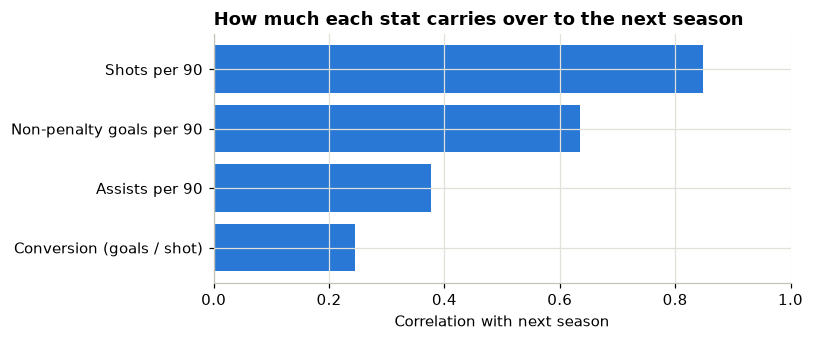

In [3]:
labels = {"shots_per90": "Shots per 90", "np_goals_per90": "Non-penalty goals per 90",
          "assists_per90": "Assists per 90", "conversion": "Conversion (goals / shot)"}
rows = []
for column, label in labels.items():
    both = pairs[[column, f"{column}_next"]].dropna()
    rows.append({"stat": label, "players": len(both), "year-to-year r": both.corr().iloc[0, 1]})
persistence = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.barh(persistence["stat"][::-1], persistence["year-to-year r"][::-1], color=BLUE)
ax.set(title="How much each stat carries over to the next season", xlabel="Correlation with next season", xlim=(0, 1))
plt.tight_layout()
persistence.round(3)

A clear ladder:

| Stat | Year-to-year r | Reading |
|---|---|---|
| Shots per 90 | about 0.85 | Very repeatable. How often a player shoots is mostly about role and style. |
| Non-penalty goals per 90 | about 0.64 | Fairly repeatable, largely because shot volume is. |
| Assists per 90 | about 0.38 | Weaker. Assists depend on team-mates finishing. |
| Conversion rate | about 0.25 | Mostly noise over a UCL season, even with 10+ shots. |

This is the main reason the Finishing page warns against reading too much into "goals above average", and
why the Player page shows intervals around per-90 rates.

## How wide is the uncertainty on a per-90 rate?

`poisson_rate_interval` in `src/analysis/player_metrics.py` gives an exact Poisson range. Here's what it
looks like for a few typical cases.

In [4]:
from src.analysis.player_metrics import poisson_rate_interval

cases = pd.DataFrame({"goals": [1, 3, 6, 12], "minutes": [90, 450, 900, 1080]})
lower, upper = poisson_rate_interval(cases["goals"], cases["minutes"])
cases["goals_per90"] = cases["goals"] * 90 / cases["minutes"]
cases["90% range"] = [f"{lo:.2f} to {hi:.2f}" for lo, hi in zip(lower, upper)]
cases.round(2)

,goals,minutes,goals_per90,90% range
0,1,90,1.0,0.05 to 4.74
1,3,450,0.6,0.16 to 1.55
2,6,900,0.6,0.26 to 1.18
3,12,1080,1.0,0.58 to 1.62


One goal in one game "is" a rate of 1.0 per 90, but anything from about 0.05 to 4.7 fits. Even 12 goals in
12 full games leaves a range of roughly 0.6 to 1.6. That's why the default minimum is 270 minutes and why
the interval is drawn on the chart instead of just ranking the point estimates.

## Conclusion

- Volume stats (shots per 90) are stable from season to season; efficiency stats (conversion) mostly aren't.
- A single UCL season is a small sample for any per-90 number, so intervals matter.
- Player defensive work can't be analysed at all with this data, since ESPN only has tackles and
  interceptions at team level.